# Compare Predictions of Redshift by Masking Percent
The goal of this notebook is to predict redshift values across original and reconstructed images for analysis


## 0.1 Imports
Upload the files from /
storage /
ice-shared /
cs7643 /
shared-group-project-data /
the-space-cats /
the-space-cats-project /
experiments / ...mask_nn

In [ ]:
import h5py

file_path = '/content/data/testing_outputs_best.hdf5'

try:
    with h5py.File(file_path, 'r') as f:
        print(f"Successfully opened HDF5 file: {file_path}")
        print("Keys in the HDF5 file (top-level datasets/groups):")
        for key in f.keys():
            print(f"- {key}")
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
except Exception as e:
    print(f"An error occurred while trying to read the HDF5 file: {e}")

Successfully opened HDF5 file: /content/data/testing_outputs_best.hdf5
Keys in the HDF5 file (top-level datasets/groups):
- masked_region_map
- original_id
- x_masked_image
- y_recon_image
- y_specz_redshift
- y_target_image
- z_latent_map
- z_latent_vector


## 1.0 Load CNN

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import h5py
import numpy as np
import pandas as pd
from einops import rearrange

# arch from CNN experiments:
class RedshiftCNN(nn.Module):
    def __init__(self, num_channels=5, output_dim=1, input_image_size=(64, 64)):
        super(RedshiftCNN, self).__init__()

        # Input: 5 channels, 64x64 image
        self.conv1 = nn.Conv2d(in_channels=num_channels, out_channels=32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv4 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        # fully connected layers
        self.fc1 = nn.Linear(256 * 4 * 4, 512)
        self.dropout = nn.Dropout(0.25)
        self.fc2 = nn.Linear(512, 1)

    def forward(self, x):
        # Apply Conv -> ReLU -> Pool for each block
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))
        x = self.pool4(F.relu(self.conv4(x)))

        # Flatten the output for the fully connected layers
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

## 1.1 Load Trained CNN Weights
make sure you upload the pth file (redshift_cnn_model)

In [2]:
model_path = '/content/data/redshift_cnn_model.pth'

input_image_size = (64, 64)
model = RedshiftCNN(num_channels=5, output_dim=1, input_image_size=input_image_size)

# Check if CUDA is available and use it
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.load_state_dict(torch.load(model_path, map_location=device))

# model in eval mode
model.eval()

RedshiftCNN(
  (conv1): Conv2d(5, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=512, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=512, out_features=1, bias=True)
)

# 2.0 Case Study
Try to get evaluation working for one individual reconstruction and regular

## 2.1 Load Dataset

In [4]:
import h5py
import numpy as np

hdf5_file_path = '/content/data/testing_outputs_best_baseline.hdf5' # Corrected file path

try:
    with h5py.File(hdf5_file_path, 'r') as f:
        y_target_image_data = f['y_target_image'][()]
        y_recon_image_data = f['y_recon_image'][()]
        y_specz_redshift_data = f['y_specz_redshift'][()]
    print(f"Successfully loaded baseline dataset from {hdf5_file_path}")
except FileNotFoundError:
    print(f"Error: File not found for baseline at {hdf5_file_path}")
except Exception as e:
    print(f"An error occurred while loading baseline dataset: {e}")

Successfully loaded baseline dataset from /content/data/testing_outputs_best_baseline.hdf5


## 2.2 "De" normalize images
transform images back to their original state, based on the transform applied to the reconstructions

In [ ]:
orig_min = -137.3596649169922
orig_max = 852.43115234375
norm_min = 0.0
norm_max = 1.0

norm_span = norm_max - norm_min
orig_span = orig_max - orig_min

# Revert the min-max normalization
y_recon_image_restored = (y_recon_image_data - norm_min) / norm_span * orig_span + orig_min
y_target_image_restored = (y_target_image_data - norm_min) / norm_span * orig_span + orig_min

print("Images successfully restored to their original scale.")

Images successfully restored to their original scale.


## 2.3 Normalize according to CNN strategy

In [ ]:
import numpy as np
from einops import rearrange

print("\n--- Normalizing Images (per-channel using training stats) ---")

channel_means = np.array([0.21533734, 0.45367402, 0.68543416, 0.8832283, 1.0558323])
channel_stds = np.array([1.0022058, 1.9175421, 3.0707815, 3.8724658, 4.5129385])

print(f"Channel means: {channel_means}")
print(f"Channel stds: {channel_stds}")

# Normalize the datasets using the means and stds
y_target_image_data_normalized = (y_target_image_restored - rearrange(channel_means, 'c -> 1 c 1 1')) / rearrange(channel_stds, 'c -> 1 c 1 1')
y_recon_image_data_normalized = (y_recon_image_restored - rearrange(channel_means, 'c -> 1 c 1 1')) / rearrange(channel_stds, 'c -> 1 c 1 1')

print("Normalization complete.")


--- Normalizing Images (per-channel using training stats) ---
Channel means: [0.21533734 0.45367402 0.68543416 0.8832283  1.0558323 ]
Channel stds: [1.0022058 1.9175421 3.0707815 3.8724658 4.5129385]
Normalization complete.


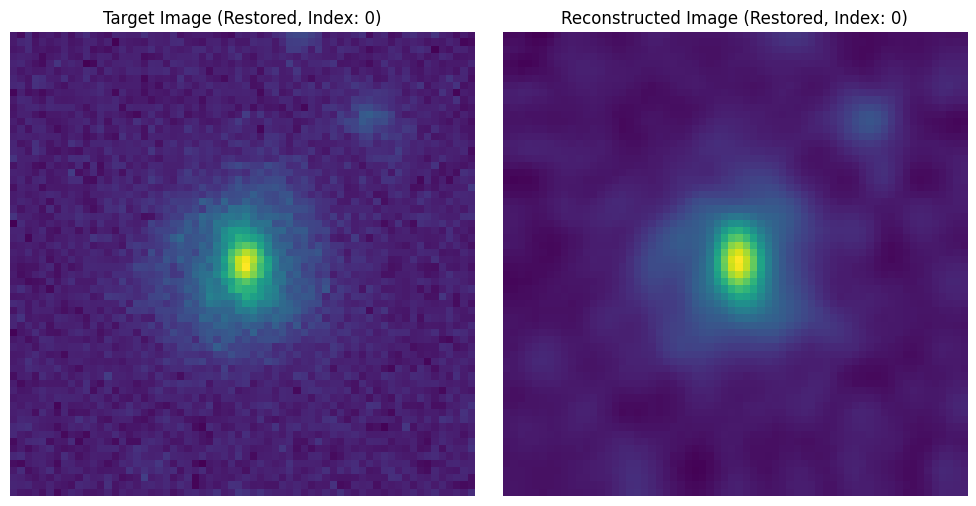

In [ ]:
import matplotlib.pyplot as plt

# Select an index to visualize
idx = 0

# The images likely have 5 channels (C, H, W), so we average across channels (axis=0) to visualize them as 2D.
target_vis = y_target_image_restored[idx].mean(axis=0)
recon_vis = y_recon_image_restored[idx].mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(target_vis, cmap='viridis')
axes[0].set_title(f'Target Image (Restored, Index: {idx})')
axes[0].axis('off')

axes[1].imshow(recon_vis, cmap='viridis')
axes[1].set_title(f'Reconstructed Image (Restored, Index: {idx})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 2.2 Evaluate Single Data Row

In [ ]:
import numpy as np
import pandas as pd
import torch

# Ensure data is available (assuming it was loaded and normalized in previous cells)
if 'y_target_image_data_normalized' in locals() and 'model' in locals():
    # Select a random index for the sample case study
    num_samples = len(y_specz_redshift_data)
    sample_idx = np.random.randint(0, num_samples)

    # Extract the normalized data for the specific sample
    orig_img_np = y_target_image_data_normalized[sample_idx]
    recon_img_np = y_recon_image_data_normalized[sample_idx]
    actual_redshift = y_specz_redshift_data[sample_idx]

    # Convert to PyTorch tensors, add batch dimension (unsqueeze(0)), and move to device
    orig_img_tensor = torch.from_numpy(orig_img_np).float().unsqueeze(0).to(device)
    recon_img_tensor = torch.from_numpy(recon_img_np).float().unsqueeze(0).to(device)

    # Perform inference
    model.eval()
    with torch.no_grad():
        pred_redshift_orig = model(orig_img_tensor).item()
        pred_redshift_recon = model(recon_img_tensor).item()

    # Calculate Deltas
    delta_orig = pred_redshift_orig - actual_redshift
    delta_recon = pred_redshift_recon - actual_redshift

    # Create a DataFrame for a clean table output matching requested format
    case_study_data = {
        'Metric': [
            'Actual Redshift',
            'Predicted Redshift',
            'Delta'
        ],
        'y_target_image': [
            actual_redshift,
            pred_redshift_orig,
            delta_orig
        ],
        'y_recon_image': [
            actual_redshift,
            pred_redshift_recon,
            delta_recon
        ]
    }

    comparison_df = pd.DataFrame(case_study_data)

    print("\n--- Redshift Prediction Comparison Table ---")
    print(comparison_df.to_markdown(index=False))
else:
    print("Please ensure the model is loaded and the data is normalized in the previous cells first.")


--- Redshift Prediction Comparison Table ---
| Metric             |   y_target_image |   y_recon_image |
|:-------------------|-----------------:|----------------:|
| Actual Redshift    |        0.0358746 |       0.0358746 |
| Predicted Redshift |        0.125276  |       0.122378  |
| Delta              |        0.0894018 |       0.0865038 |


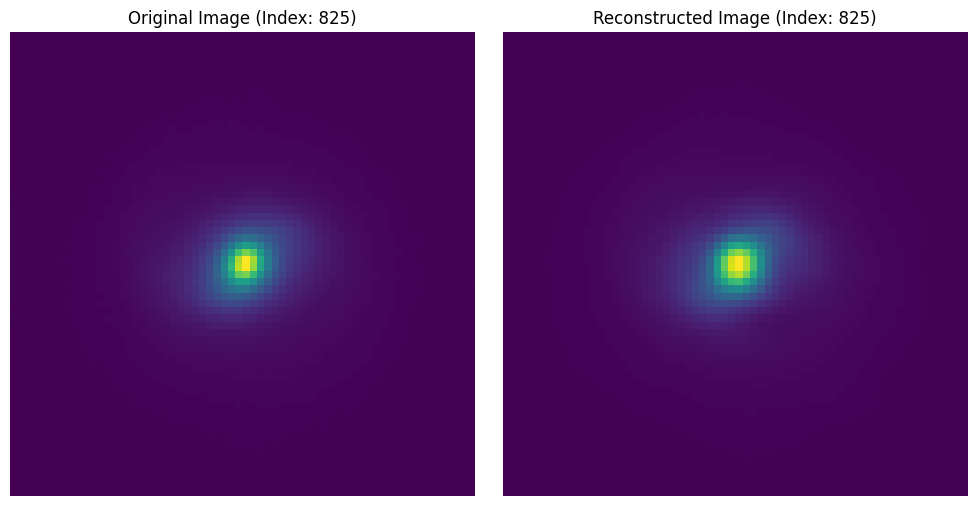

In [ ]:
import matplotlib.pyplot as plt

# Ensure we have the images from the sample case study cell
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# The images have 5 channels (C, H, W). We can visualize the average across all channels.
orig_vis = orig_img_np.mean(axis=0)
recon_vis = recon_img_np.mean(axis=0)

axes[0].imshow(orig_vis, cmap='viridis')
axes[0].set_title(f'Original Image (Index: {sample_idx})')
axes[0].axis('off')

axes[1].imshow(recon_vis, cmap='viridis')
axes[1].set_title(f'Reconstructed Image (Index: {sample_idx})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# 3.0 Evaluation for All Images
woo



In [5]:
import h5py
import numpy as np

datasets = {}
file_suffixes = {
    'baseline': '_baseline', # Original file with _baseline suffix
    '0.25': '0.25',
    '0.5': '0.5',
    '0.75': '0.75'
}

for key, suffix in file_suffixes.items():
    hdf5_file_path = f'/content/data/testing_outputs_best{suffix}.hdf5'
    try:
        with h5py.File(hdf5_file_path, 'r') as f:
            datasets[key] = {
                'y_target_image': f['y_target_image'][()],
                'y_recon_image': f['y_recon_image'][()],
                'y_specz_redshift': f['y_specz_redshift'][()]
            }
        print(f"Successfully loaded {key} dataset from {hdf5_file_path}")
    except FileNotFoundError:
        print(f"Error: File not found for {key} at {hdf5_file_path}")
    except Exception as e:
        print(f"An error occurred while loading {key} dataset: {e}")

print("\nAll datasets loaded into the 'datasets' dictionary.")

Successfully loaded baseline dataset from /content/data/testing_outputs_best_baseline.hdf5
Successfully loaded 0.25 dataset from /content/data/testing_outputs_best0.25.hdf5
Successfully loaded 0.5 dataset from /content/data/testing_outputs_best0.5.hdf5
Successfully loaded 0.75 dataset from /content/data/testing_outputs_best0.75.hdf5

All datasets loaded into the 'datasets' dictionary.


# 3.1 "De" normalize images

In [6]:
orig_min = -137.3596649169922
orig_max = 852.43115234375
norm_min = 0.0
norm_max = 1.0

norm_span = norm_max - norm_min
orig_span = orig_max - orig_min

for key in datasets:
    # Revert the min-max normalization for target images
    datasets[key]['y_target_image_restored'] = (datasets[key]['y_target_image'] - norm_min) / norm_span * orig_span + orig_min
    # Revert the min-max normalization for reconstructed images
    datasets[key]['y_recon_image_restored'] = (datasets[key]['y_recon_image'] - norm_min) / norm_span * orig_span + orig_min
    print(f"Images for dataset '{key}' successfully restored to their original scale.")

print("\nAll images across all datasets have been de-normalized.")

Images for dataset 'baseline' successfully restored to their original scale.
Images for dataset '0.25' successfully restored to their original scale.
Images for dataset '0.5' successfully restored to their original scale.
Images for dataset '0.75' successfully restored to their original scale.

All images across all datasets have been de-normalized.


## 3.2  Normalize according to CNN strategy

In [7]:
import numpy as np
from einops import rearrange

print("\n--- Normalizing Images (per-channel using training stats) for all datasets ---")

channel_means = np.array([0.21533734, 0.45367402, 0.68543416, 0.8832283, 1.0558323])
channel_stds = np.array([1.0022058, 1.9175421, 3.0707815, 3.8724658, 4.5129385])

print(f"Channel means: {channel_means}")
print(f"Channel stds: {channel_stds}")

for key in datasets:
    # Normalize the datasets using the means and stds
    datasets[key]['y_target_image_normalized'] = (datasets[key]['y_target_image_restored'] - rearrange(channel_means, 'c -> 1 c 1 1')) / rearrange(channel_stds, 'c -> 1 c 1 1')
    datasets[key]['y_recon_image_normalized'] = (datasets[key]['y_recon_image_restored'] - rearrange(channel_means, 'c -> 1 c 1 1')) / rearrange(channel_stds, 'c -> 1 c 1 1')
    print(f"Normalization complete for dataset: {key}")

print("\nAll images across all datasets have been normalized.")


--- Normalizing Images (per-channel using training stats) for all datasets ---
Channel means: [0.21533734 0.45367402 0.68543416 0.8832283  1.0558323 ]
Channel stds: [1.0022058 1.9175421 3.0707815 3.8724658 4.5129385]
Normalization complete for dataset: baseline
Normalization complete for dataset: 0.25
Normalization complete for dataset: 0.5
Normalization complete for dataset: 0.75

All images across all datasets have been normalized.


## 3.3 Compute predictions for each dataset

In [8]:
import torch
import numpy as np

# Ensure the model is in evaluation mode and on the correct device
model.eval()

# Initialize dictionaries to store predictions and actual values
predictions = {}

print("\n--- Predicting Redshifts for all datasets ---")

for key, data in datasets.items():
    print(f"Processing dataset: {key}")

    # Get normalized images and actual redshifts for the current dataset
    y_target_image_normalized = data['y_target_image_normalized']
    y_recon_image_normalized = data['y_recon_image_normalized']
    y_specz_redshift = data['y_specz_redshift']

    # Convert numpy arrays to PyTorch tensors and move to device
    target_images_tensor = torch.from_numpy(y_target_image_normalized).float().to(device)
    recon_images_tensor = torch.from_numpy(y_recon_image_normalized).float().to(device)

    with torch.no_grad():
        # Predict redshifts for target images
        predicted_redshifts_target = model(target_images_tensor).cpu().numpy().flatten()
        # Predict redshifts for reconstructed images
        predicted_redshifts_recon = model(recon_images_tensor).cpu().numpy().flatten()

    # Store the results
    predictions[key] = {
        'actual_redshift': y_specz_redshift,
        'predicted_redshift_target': predicted_redshifts_target,
        'predicted_redshift_recon': predicted_redshifts_recon
    }
    print(f"Predictions complete for dataset: {key}")

print("\nAll redshift predictions completed and stored in the 'predictions' dictionary.")



--- Predicting Redshifts for all datasets ---
Processing dataset: baseline
Predictions complete for dataset: baseline
Processing dataset: 0.25
Predictions complete for dataset: 0.25
Processing dataset: 0.5
Predictions complete for dataset: 0.5
Processing dataset: 0.75
Predictions complete for dataset: 0.75

All redshift predictions completed and stored in the 'predictions' dictionary.


## 3.4 Predict redshift and Evaluate average delta for all populations

In [9]:
import pandas as pd
import numpy as np

# Dictionary to store the average deltas for each dataset
average_deltas = {}

for dataset_name, data in predictions.items():
    actual_redshift = data['actual_redshift']
    predicted_redshift_target = data['predicted_redshift_target']
    predicted_redshift_recon = data['predicted_redshift_recon']

    # Calculate absolute delta for target images
    delta_target = predicted_redshift_target - actual_redshift
    avg_delta_target = np.mean(np.abs(delta_target))

    # Calculate absolute delta for reconstructed images
    delta_recon = predicted_redshift_recon - actual_redshift
    avg_delta_recon = np.mean(np.abs(delta_recon))

    average_deltas[dataset_name] = {
        'Average_Absolute_Delta_Target': avg_delta_target,
        'Average_Absolute_Delta_Recon': avg_delta_recon
    }

# Convert the results to a pandas DataFrame for a nice table display
deltas_df = pd.DataFrame.from_dict(average_deltas, orient='index')
deltas_df.index.name = 'Dataset'

print("--- Average Absolute Deltas for Each Dataset ---")
print(deltas_df.to_markdown())

--- Average Absolute Deltas for Each Dataset ---
| Dataset   |   Average_Absolute_Delta_Target |   Average_Absolute_Delta_Recon |
|:----------|--------------------------------:|-------------------------------:|
| baseline  |                        0.434148 |                       0.424895 |
| 0.25      |                        0.433119 |                       0.683765 |
| 0.5       |                        0.434148 |                       0.355341 |
| 0.75      |                        0.433119 |                       0.133159 |


In [16]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Dictionary to store performance metrics for each dataset
performance_metrics = {}

print("--- Redshift Prediction Performance Metrics for Each Dataset ---")

for dataset_name, data in predictions.items():
    actual_redshift = data['actual_redshift']
    predicted_redshift_target = data['predicted_redshift_target']
    predicted_redshift_recon = data['predicted_redshift_recon']

    # Metrics for Target Images
    mae_target = mean_absolute_error(actual_redshift, predicted_redshift_target)
    rmse_target = np.sqrt(mean_squared_error(actual_redshift, predicted_redshift_target))
    mean_error_target = np.mean(predicted_redshift_target - actual_redshift)
    std_error_target = np.std(predicted_redshift_target - actual_redshift)

    # Metrics for Reconstructed Images
    mae_recon = mean_absolute_error(actual_redshift, predicted_redshift_recon)
    rmse_recon = np.sqrt(mean_squared_error(actual_redshift, predicted_redshift_recon))
    mean_error_recon = np.mean(predicted_redshift_recon - actual_redshift)
    std_error_recon = np.std(predicted_redshift_recon - actual_redshift)

    performance_metrics[dataset_name] = {
        'Target_MAE': mae_target,
        'Target_RMSE': rmse_target,
        'Target_Mean_Error': mean_error_target,
        'Target_Std_Error': std_error_target,
        'Recon_MAE': mae_recon,
        'Recon_RMSE': rmse_recon,
        'Recon_Mean_Error': mean_error_recon,
        'Recon_Std_Error': std_error_recon
    }

# Convert the results to a pandas DataFrame for a nice table display
metrics_df = pd.DataFrame.from_dict(performance_metrics, orient='index')
metrics_df.index.name = 'Dataset'

print(metrics_df.to_markdown(floatfmt=".4f"))

--- Redshift Prediction Performance Metrics for Each Dataset ---
| Dataset   |   Target_MAE |   Target_RMSE |   Target_Mean_Error |   Target_Std_Error |   Recon_MAE |   Recon_RMSE |   Recon_Mean_Error |   Recon_Std_Error |
|:----------|-------------:|--------------:|--------------------:|-------------------:|------------:|-------------:|-------------------:|------------------:|
| baseline  |       0.4341 |        0.5695 |              0.4341 |             0.3686 |      0.4249 |       0.5719 |             0.4249 |            0.3829 |
| 0.25      |       0.4331 |        0.5696 |              0.4331 |             0.3699 |      0.6838 |       0.7776 |             0.6816 |            0.3744 |
| 0.5       |       0.4341 |        0.5695 |              0.4341 |             0.3686 |      0.3553 |       0.4416 |             0.3447 |            0.2760 |
| 0.75      |       0.4331 |        0.5696 |              0.4331 |             0.3699 |      0.1332 |       0.1633 |             0.0744 |        

## 3.5 Visualize trends across masking datasets

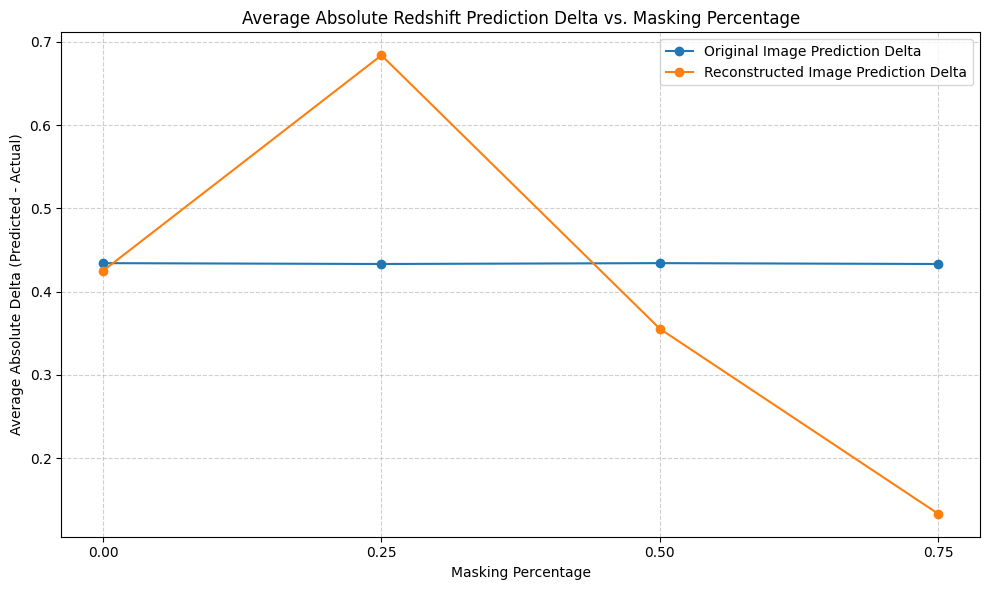

The plot above visualizes the average absolute deltas for both original and reconstructed images across different masking percentages.
As you noted, it shows a peculiar trend where the reconstructed image's prediction delta decreases significantly with higher masking, indicating potentially better predictions than expected.


In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Prepare data for plotting
# Replace 'baseline' with 0 for numerical sorting and plotting
plot_df = deltas_df.copy()
plot_df = plot_df.rename(index={'baseline': '0'})
plot_df.index = plot_df.index.astype(float)
plot_df = plot_df.sort_index()

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(plot_df.index, plot_df['Average_Absolute_Delta_Target'], marker='o', label='Original Image Prediction Delta')
plt.plot(plot_df.index, plot_df['Average_Absolute_Delta_Recon'], marker='o', label='Reconstructed Image Prediction Delta')

plt.title('Average Absolute Redshift Prediction Delta vs. Masking Percentage')
plt.xlabel('Masking Percentage')
plt.ylabel('Average Absolute Delta (Predicted - Actual)')
plt.xticks(plot_df.index, labels=[f'{x:.2f}' for x in plot_df.index])
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

print("The plot above visualizes the average absolute deltas for both original and reconstructed images across different masking percentages.")
print("As you noted, it shows a peculiar trend where the reconstructed image's prediction delta decreases significantly with higher masking, indicating potentially better predictions than expected.")

Visualizing sample with index: 1619


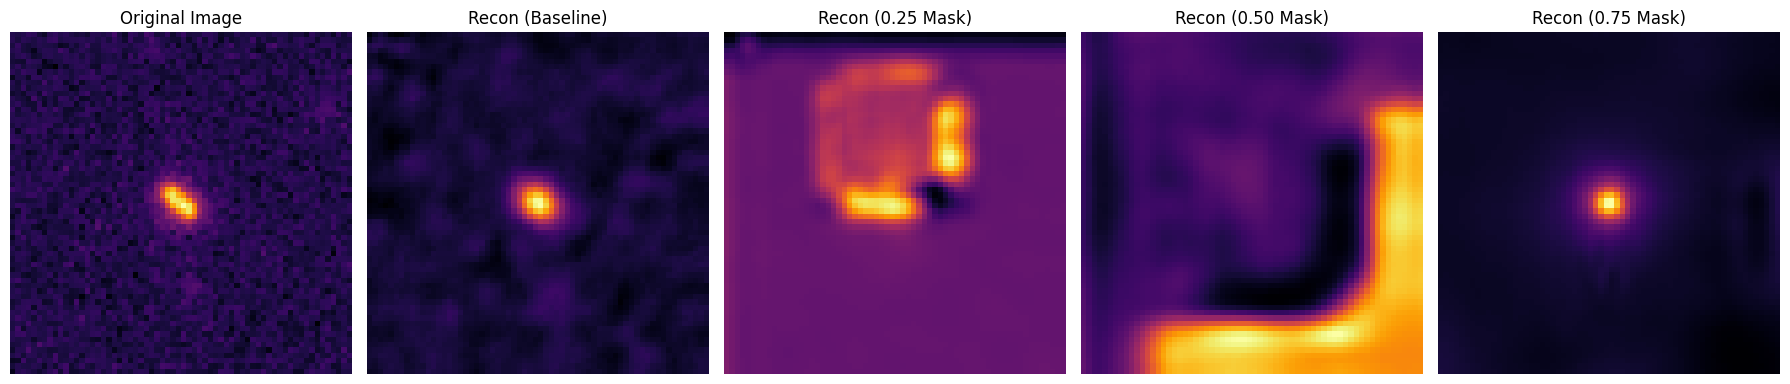

The plots above show the original image and its reconstructed versions for different masking percentages for a single sample.


In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Select a random sample index to visualize
num_samples = len(datasets['baseline']['y_target_image_restored'])
sample_idx = np.random.randint(0, num_samples)

print(f"Visualizing sample with index: {sample_idx}")

# Prepare images for plotting
# Original image (from baseline target)
original_image = datasets['baseline']['y_target_image_restored'][sample_idx]

# Reconstructed images from different masking percentages
recon_baseline = datasets['baseline']['y_recon_image_restored'][sample_idx]
recon_025 = datasets['0.25']['y_recon_image_restored'][sample_idx]
recon_05 = datasets['0.5']['y_recon_image_restored'][sample_idx]
recon_075 = datasets['0.75']['y_recon_image_restored'][sample_idx]

images_to_plot = [
    original_image,
    recon_baseline,
    recon_025,
    recon_05,
    recon_075
]

titles = [
    'Original Image',
    'Recon (Baseline)',
    'Recon (0.25 Mask)',
    'Recon (0.50 Mask)',
    'Recon (0.75 Mask)'
]

fig, axes = plt.subplots(1, len(images_to_plot), figsize=(18, 5))

for i, (image, title) in enumerate(zip(images_to_plot, titles)):
    # Average across the 5 channels for visualization
    vis_image = image.mean(axis=0)
    axes[i].imshow(vis_image, cmap='inferno')
    axes[i].set_title(title)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print("The plots above show the original image and its reconstructed versions for different masking percentages for a single sample.")

In [27]:
import pandas as pd

# Assuming sample_idx is still available from the previous cell execution
# If not, you might need to re-run the image visualization cell or define it again.
# For consistency, we'll use the previously generated sample_idx.

# Get the actual redshift for the sample
actual_redshift_sample = predictions['baseline']['actual_redshift'][sample_idx]

# Get the predicted redshift for the original image (target) of the sample
# This should be consistent across all datasets as the target is the same
predicted_redshift_original = predictions['baseline']['predicted_redshift_target'][sample_idx]

# Get predicted redshifts for reconstructed images for the sample
predicted_recon_baseline = predictions['baseline']['predicted_redshift_recon'][sample_idx]
predicted_recon_025 = predictions['0.25']['predicted_redshift_recon'][sample_idx]
predicted_recon_05 = predictions['0.5']['predicted_redshift_recon'][sample_idx]
predicted_recon_075 = predictions['0.75']['predicted_redshift_recon'][sample_idx]

# Create a DataFrame to display the predictions
redshift_predictions_data = {
    'Image Type': [
        'Actual Redshift',
        'Original Image Prediction',
        'Recon (Baseline) Prediction',
        'Recon (0.25 Mask) Prediction',
        'Recon (0.50 Mask) Prediction',
        'Recon (0.75 Mask) Prediction'
    ],
    'Redshift Value': [
        actual_redshift_sample,
        predicted_redshift_original,
        predicted_recon_baseline,
        predicted_recon_025,
        predicted_recon_05,
        predicted_recon_075
    ]
}

redshift_predictions_df = pd.DataFrame(redshift_predictions_data)

print(f"--- Redshift Predictions for Sample Index: {sample_idx} ---")
print(redshift_predictions_df.to_markdown(index=False))


--- Redshift Predictions for Sample Index: 1619 ---
| Image Type                   |   Redshift Value |
|:-----------------------------|-----------------:|
| Actual Redshift              |         0.224778 |
| Original Image Prediction    |         0.95329  |
| Recon (Baseline) Prediction  |         0.770641 |
| Recon (0.25 Mask) Prediction |         1.34587  |
| Recon (0.50 Mask) Prediction |         0.77496  |
| Recon (0.75 Mask) Prediction |         0.229854 |
